In [12]:
!pip install timm
!pip install torch torchvision
!pip install tqdm
!pip install scikit-learn
!pip install grad-cam

  Using cached timm-1.0.27-py3-none-any.whl.metadata (40 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
Using cached timm-1.0.27-py3-none-any.whl (2.6 MB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [timm]1/2 [timm]

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


create a validation folder  

In [13]:
import os
import random
import shutil

# ================================
# Dataset Paths
# ================================

TRAIN_DIR = "/content/drive/MyDrive/dataset/train"
VAL_DIR = "dataset/val"

# Validation split percentage
VAL_SPLIT = 0.2

# Create validation directory
os.makedirs(VAL_DIR, exist_ok=True)

# ================================
# Create validation set
# ================================

# ================================
# Create validation set
# ================================

# Ignore hidden files like .DS_Store
classes = [
    cls for cls in os.listdir(TRAIN_DIR)
    if not cls.startswith(".")
]

for cls in classes:

    train_class_path = os.path.join(TRAIN_DIR, cls)
    val_class_path = os.path.join(VAL_DIR, cls)

    os.makedirs(val_class_path, exist_ok=True)

    images = os.listdir(train_class_path)

    # Shuffle images randomly
    random.shuffle(images)

    # Number of validation images
    val_size = int(len(images) * VAL_SPLIT)

    val_images = images[:val_size]

    train_class_path = os.path.join(TRAIN_DIR, cls)
    val_class_path = os.path.join(VAL_DIR, cls)

    os.makedirs(val_class_path, exist_ok=True)

    images = os.listdir(train_class_path)

    # Shuffle images randomly
    random.shuffle(images)

    # Number of validation images
    val_size = int(len(images) * VAL_SPLIT)

    val_images = images[:val_size]

    print(f"\nProcessing Class: {cls}")
    print(f"Moving {val_size} images to validation folder")

    for img in val_images:

        src = os.path.join(train_class_path, img)
        dst = os.path.join(val_class_path, img)

        shutil.move(src, dst)

print("\nValidation dataset created successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset/train'

Preprocessing and store in a file

In [14]:
import os
import cv2
import numpy as np

# =========================================================
# INPUT DATASET PATH
# =========================================================

INPUT_DATASET = "/Users/apple/Documents/SEM-2/thesis/code/dataset"

# =========================================================
# OUTPUT DATASET PATH
# =========================================================

OUTPUT_DATASET = "/Users/apple/Documents/SEM-2/thesis/code/processed_dataset"

# =========================================================
# IMAGE SIZE
# Higher resolution preserves MRI details
# =========================================================

IMAGE_SIZE = 512

# =========================================================
# CLAHE
# Improves local contrast
# =========================================================

def apply_clahe(image):

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Improved CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    return enhanced


# =========================================================
# UNSHARP MASKING
# Enhances tumor edges
# =========================================================

def unsharp_mask(image):

    # Light Gaussian blur
    blurred = cv2.GaussianBlur(
        image,
        (3, 3),
        1.0
    )

    # Improved sharpening
    sharpened = cv2.addWeighted(
        image,
        1.3,
        blurred,
        -0.3,
        0
)

    return sharpened


# =========================================================
# HYBRID FILTERING
# Median + Bilateral
# Preserves edges and removes noise
# =========================================================

def hybrid_filter(image):

    # Median filtering
    median = cv2.medianBlur(
        image,
        3
    )

    # Bilateral filtering
    bilateral = cv2.bilateralFilter(
        median,
        d=7,
        sigmaColor=50,
        sigmaSpace=50
    )

    return bilateral


# =========================================================
# NORMALIZATION
# =========================================================

def normalize_image(image):

    normalized = image / 255.0

    return normalized


# =========================================================
# COMPLETE PREPROCESSING
# =========================================================

def preprocess_image(image_path):

    # Read image
    image = cv2.imread(image_path)

    # Check image
    if image is None:

        print(f"Could not read image: {image_path}")
        return None

    # =====================================================
    # HIGH QUALITY RESIZE
    # =====================================================

    image = cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_CUBIC
    )

    # =====================================================
    # STEP 1: CLAHE
    # =====================================================

    clahe_img = apply_clahe(image)

    # =====================================================
    # STEP 2: UNSHARP MASK
    # =====================================================

    sharp_img = unsharp_mask(clahe_img)

    # =====================================================
    # STEP 3: HYBRID FILTER
    # =====================================================

    filtered_img = hybrid_filter(sharp_img)

    # =====================================================
    # STEP 4: NORMALIZATION
    # =====================================================

    normalized_img = normalize_image(
        filtered_img
    )

    # Convert back for saving
    final_img = (
        normalized_img * 255
    ).astype(np.uint8)

    return final_img


# =========================================================
# PROCESS COMPLETE DATASET
# =========================================================

def process_dataset():

    dataset_types = [
        "train",
        "val",
        "test"
    ]

    for dtype in dataset_types:

        input_type_path = os.path.join(
            INPUT_DATASET,
            dtype
        )

        output_type_path = os.path.join(
            OUTPUT_DATASET,
            dtype
        )

        # Ignore hidden files
        classes = [
            cls for cls in os.listdir(input_type_path)
            if not cls.startswith(".")
        ]

        for cls in classes:

            input_class_path = os.path.join(
                input_type_path,
                cls
            )

            output_class_path = os.path.join(
                output_type_path,
                cls
            )

            os.makedirs(
                output_class_path,
                exist_ok=True
            )

            images = [
                img for img in os.listdir(input_class_path)
                if not img.startswith(".")
            ]

            print("\n===================================")
            print(f"Processing: {dtype}/{cls}")
            print(f"Total Images: {len(images)}")
            print("===================================")

            for img_name in images:

                input_image_path = os.path.join(
                    input_class_path,
                    img_name
                )

                output_image_path = os.path.join(
                    output_class_path,
                    img_name
                )

                # Preprocess image
                processed_img = preprocess_image(
                    input_image_path
                )

                # Save processed image
                if processed_img is not None:

                    cv2.imwrite(
                        output_image_path,
                        processed_img
                    )

            print(f"Completed: {cls}")

    print("\n===================================")
    print("FULL DATASET PREPROCESSING COMPLETED")
    print("===================================")


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    process_dataset()


Processing: train/pituitary
Total Images: 747
Completed: pituitary

Processing: train/no_tumor
Total Images: 548
Completed: no_tumor

Processing: train/glioma
Total Images: 918
Completed: glioma

Processing: train/meningioma
Total Images: 1064
Completed: meningioma

Processing: val/pituitary
Total Images: 710
Completed: pituitary

Processing: val/no_tumor
Total Images: 519
Completed: no_tumor

Processing: val/glioma
Total Images: 229
Completed: glioma

Processing: val/meningioma
Total Images: 265
Completed: meningioma

Processing: test/pituitary
Total Images: 300
Completed: pituitary

Processing: test/no_tumor
Total Images: 140
Completed: no_tumor

Processing: test/glioma
Total Images: 254
Completed: glioma

Processing: test/meningioma
Total Images: 306
Completed: meningioma

FULL DATASET PREPROCESSING COMPLETED


starting the models


In [15]:
import torch
import torch.nn as nn
import timm

Models: CBAM

In [16]:
# =========================================================
# CHANNEL ATTENTION
# =========================================================

class ChannelAttention(nn.Module):

    def __init__(self, in_channels, reduction_ratio=16):

        super(ChannelAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(

            nn.Conv2d(
                in_channels,
                in_channels // reduction_ratio,
                1,
                bias=False
            ),

            nn.ReLU(),

            nn.Conv2d(
                in_channels // reduction_ratio,
                in_channels,
                1,
                bias=False
            )
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.fc(
            self.avg_pool(x)
        )

        max_out = self.fc(
            self.max_pool(x)
        )

        out = avg_out + max_out

        return self.sigmoid(out)


# =========================================================
# SPATIAL ATTENTION
# =========================================================

class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):

        super(SpatialAttention, self).__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_out, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        concat = torch.cat(
            [avg_out, max_out],
            dim=1
        )

        out = self.conv(concat)

        return self.sigmoid(out)


# =========================================================
# COMPLETE CBAM
# =========================================================

class CBAM(nn.Module):

    def __init__(self, in_channels):

        super(CBAM, self).__init__()

        self.channel_attention = ChannelAttention(
            in_channels
        )

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        x = x * self.channel_attention(x)

        x = x * self.spatial_attention(x)

        return x

Models: convnext_mamba

In [17]:
# =========================================================
# SIMPLE MAMBA-STYLE BLOCK
# =========================================================

class MambaBlock(nn.Module):

    def __init__(self, dim):

        super(MambaBlock, self).__init__()

        self.norm = nn.LayerNorm(dim)

        self.linear1 = nn.Linear(dim, dim)

        self.gelu = nn.GELU()

        self.linear2 = nn.Linear(dim, dim)

    def forward(self, x):

        residual = x

        x = self.norm(x)

        x = self.linear1(x)

        x = self.gelu(x)

        x = self.linear2(x)

        x = x + residual

        return x

mamba block

In [18]:
# =========================================================
# CONVNEXT + CBAM + MAMBA
# =========================================================

class ConvNeXtMamba(nn.Module):

    def __init__(self, num_classes=4):

        super(ConvNeXtMamba, self).__init__()

        # =================================================
        # CONVNEXT BACKBONE
        # =================================================

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0,
            in_chans=3
        )

        feature_dim = 768

        # =================================================
        # CBAM
        # =================================================

        self.cbam = CBAM(feature_dim)

        # =================================================
        # MAMBA BLOCK
        # =================================================

        self.mamba = MambaBlock(feature_dim)

        # =================================================
        # CLASSIFIER
        # =================================================

        self.classifier = nn.Sequential(

            nn.Linear(feature_dim, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        # ================================================
        # Convert grayscale to pseudo RGB
        # ================================================

        if x.shape[1] == 1:

            x = x.repeat(1, 3, 1, 1)

        # ================================================
        # ConvNeXt Features
        # ================================================

        x = self.backbone.forward_features(x)

        # Shape:
        # [B, C, H, W]

        # ================================================
        # CBAM
        # ================================================

        x = self.cbam(x)

        # ================================================
        # Global Average Pooling
        # ================================================

        x = torch.mean(
            x,
            dim=[2, 3]
        )

        # ================================================
        # Mamba Block
        # ================================================

        x = self.mamba(x)

        # ================================================
        # Classification
        # ================================================

        x = self.classifier(x)

        return x

Training:
Dataset loader

In [19]:
# =========================================================
# DEVICE CONFIGURATION
# =========================================================

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cpu


In [20]:
model = ConvNeXtMamba(
    num_classes=4
)

model = model.to(device)

print(model)

ConvNeXtMamba(
  (backbone): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=384, out_features=96, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
 

In [21]:
# =========================================================
# LOSS FUNCTION
# =========================================================

criterion = nn.CrossEntropyLoss()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# =========================================================
# LEARNING RATE SCHEDULER
# =========================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [22]:
# =========================================================
# ACCURACY FUNCTION
# =========================================================

def calculate_accuracy(outputs, labels):

    _, preds = torch.max(outputs, 1)

    correct = (preds == labels).sum().item()

    accuracy = correct / labels.size(0)

    return accuracy

In [23]:
# =========================================================
# TRAINING SETTINGS
# =========================================================

EPOCHS = 20

best_val_accuracy = 0.0

train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

In [24]:
!pip install tqdm


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [33]:
from torchvision import transforms

# =========================================================
# TRAIN TRANSFORMS
# =========================================================

train_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

# =========================================================
# VALIDATION / TEST TRANSFORMS
# =========================================================

val_test_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [35]:
from torchvision import datasets
PROCESSED_PATH='/Users/apple/Documents/SEM-2/thesis/code/processed_dataset'

# =========================================================
# DATASETS
# =========================================================

train_dataset = datasets.ImageFolder(
    os.path.join(PROCESSED_PATH, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    os.path.join(PROCESSED_PATH, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(PROCESSED_PATH, "test"),
    transform=val_test_transforms
)

print("Classes:")
print(train_dataset.classes)

Classes:
['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [36]:
from torch.utils.data import DataLoader

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 205
Validation batches: 108
Test batches: 63


In [30]:
from tqdm import tqdm

path ='/content/model'
# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # =====================================================
    # TRAINING MODE
    # =====================================================

    model.train()

    running_train_loss = 0.0

    running_train_accuracy = 0.0

    # =====================================================
    # TRAIN LOOP
    # =====================================================

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Metrics
        running_train_loss += loss.item()

        running_train_accuracy += calculate_accuracy(
            outputs,
            labels
        )

    # =====================================================
    # AVERAGE TRAIN METRICS
    # =====================================================

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )

    epoch_train_accuracy = (
        running_train_accuracy / len(train_loader)
    )

    # =====================================================
    # VALIDATION MODE
    # =====================================================

    model.eval()

    running_val_loss = 0.0

    running_val_accuracy = 0.0

    # =====================================================
    # VALIDATION LOOP
    # =====================================================

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            running_val_accuracy += calculate_accuracy(
                outputs,
                labels
            )

    # =====================================================
    # AVERAGE VALIDATION METRICS
    # =====================================================

    epoch_val_loss = (
        running_val_loss / len(val_loader)
    )

    epoch_val_accuracy = (
        running_val_accuracy / len(val_loader)
    )

    # =====================================================
    # STORE METRICS
    # =====================================================

    train_losses.append(epoch_train_loss)

    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)

    val_accuracies.append(epoch_val_accuracy)

    # =====================================================
    # LEARNING RATE SCHEDULER
    # =====================================================

    scheduler.step(epoch_val_loss)

    # =====================================================
    # PRINT METRICS
    # =====================================================

    print(f"\nTrain Loss: {epoch_train_loss:.4f}")

    print(f"Train Accuracy: {epoch_train_accuracy:.4f}")

    print(f"Validation Loss: {epoch_val_loss:.4f}")

    print(f"Validation Accuracy: {epoch_val_accuracy:.4f}")

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        model_save_path = os.path.join(
            path,
            "best_model.pth"
        )

        torch.save(
            model.state_dict(),
            model_save_path
        )

        print("\nBest Model Saved")


Epoch [1/20]


100%|██████████| 191/191 [01:13<00:00,  2.59it/s]



Train Loss: 0.2307
Train Accuracy: 0.9280
Validation Loss: 0.2334
Validation Accuracy: 0.9236

Best Model Saved

Epoch [2/20]


100%|██████████| 191/191 [01:13<00:00,  2.60it/s]



Train Loss: 0.1897
Train Accuracy: 0.9444
Validation Loss: 0.1060
Validation Accuracy: 0.9641

Best Model Saved

Epoch [3/20]


...


Train Loss: 0.0018
Train Accuracy: 0.9993
Validation Loss: 0.0443
Validation Accuracy: 0.9884

Epoch [19/20]


100%|██████████| 191/191 [01:13<00:00,  2.60it/s]



Train Loss: 0.0008
Train Accuracy: 0.9997
Validation Loss: 0.0456
Validation Accuracy: 0.9867

Epoch [20/20]


100%|██████████| 191/191 [01:13<00:00,  2.61it/s]



Train Loss: 0.0010
Train Accuracy: 0.9997
Validation Loss: 0.0472
Validation Accuracy: 0.9890


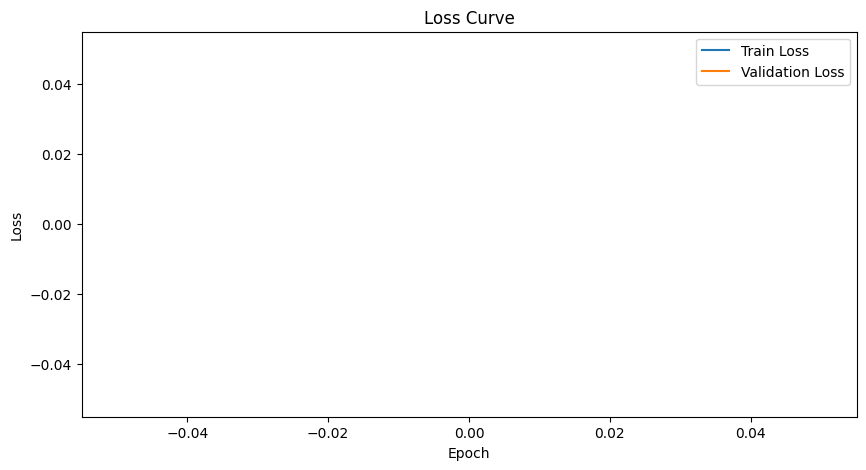

In [49]:
import matplotlib.pyplot as plt
# =========================================================
# TRAINING LOSS GRAPH
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

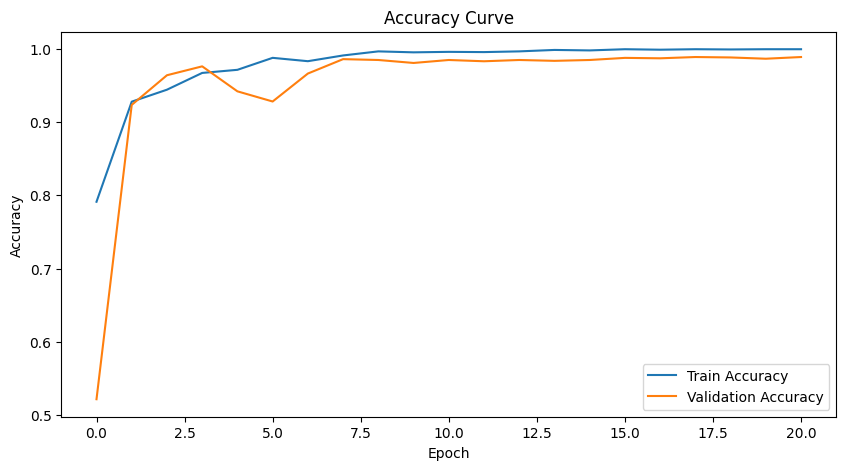

In [33]:
# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

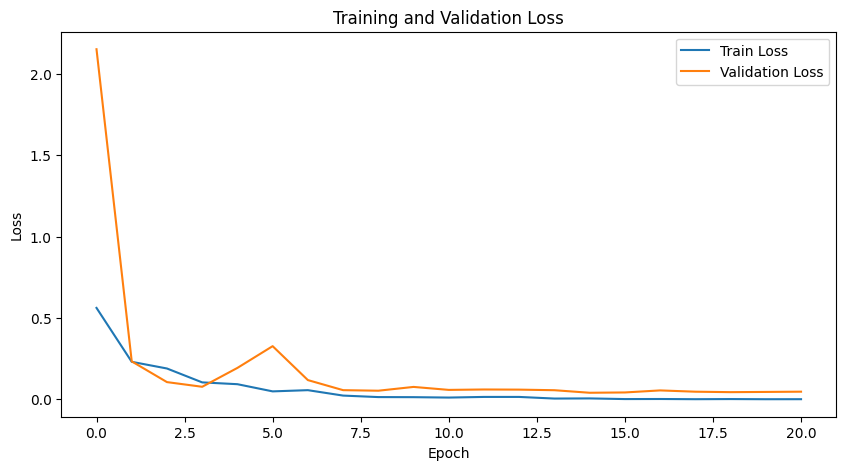

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

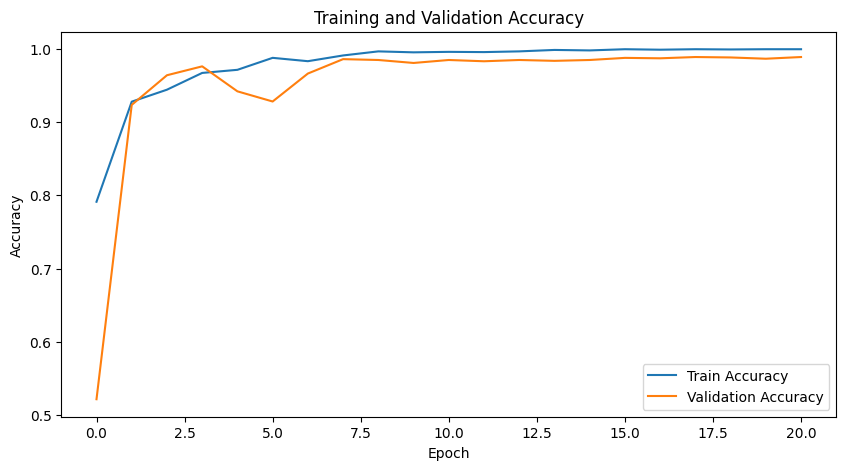

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [27]:
import os
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CHECKPOINT_PATH_Model = "/Users/apple/Documents/SEM-2/thesis/code/"

model.load_state_dict(
    torch.load(
        os.path.join(
            CHECKPOINT_PATH_Model,
            "best_model.pth"
        ),
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Best Model Loaded")

Best Model Loaded



Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       254
  meningioma       0.98      0.99      0.99       306
    no_tumor       0.99      1.00      1.00       140
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



<Figure size 800x800 with 0 Axes>

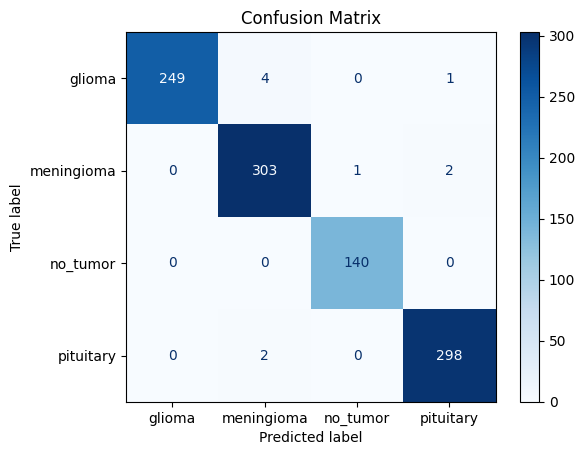

In [37]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

all_labels = []

all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [38]:
!pip install grad-cam gradio -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [39]:
import gradio as gr
import numpy as np
import cv2
import torch
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [40]:
class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

In [41]:
MODEL_PATH = "/Users/apple/Documents/SEM-2/thesis/code/best_model.pth"

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [42]:
target_layers = [
    model.backbone.stages[-1].blocks[-1]
]
model.backbone.stages[-1]

ConvNeXtStage(
  (downsample): Sequential(
    (0): LayerNorm2d((384,), eps=1e-06, elementwise_affine=True, bias=True)
    (1): Conv2d(384, 768, kernel_size=(2, 2), stride=(2, 2))
  )
  (blocks): Sequential(
    (0): ConvNeXtBlock(
      (conv_dw): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
      (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU()
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
      (shortcut): Identity()
      (drop_path): Identity()
    )
    (1): ConvNeXtBlock(
      (conv_dw): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
      (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
  

In [43]:
from torchvision import transforms

predict_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

In [44]:
def preprocess_for_prediction(image):

    image = np.array(image)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    image = cv2.resize(
        image,
        (224, 224)
    )

    # CLAHE
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    clahe_img = clahe.apply(gray)

    # Unsharp Masking
    blurred = cv2.GaussianBlur(
        clahe_img,
        (3, 3),
        1
    )

    sharp = cv2.addWeighted(
        clahe_img,
        1.3,
        blurred,
        -0.3,
        0
    )

    # Hybrid Filter
    filtered = cv2.bilateralFilter(
        sharp,
        d=7,
        sigmaColor=50,
        sigmaSpace=50
    )

    return filtered

In [45]:
def predict_tumor(image):

    # =====================================================
    # PREPROCESS
    # =====================================================

    processed_img = preprocess_for_prediction(image)

    # Convert grayscale to PIL
    pil_image = Image.fromarray(processed_img)

    # Tensor
    tensor = predict_transform(pil_image)

    # Add batch dimension
    tensor = tensor.unsqueeze(0)

    # =====================================================
    # IMPORTANT FIX
    # Convert 1-channel → 3-channel
    # =====================================================

    tensor = tensor.repeat(1, 3, 1, 1)

    tensor = tensor.to(device)

    # =====================================================
    # PREDICTION
    # =====================================================

    with torch.no_grad():

        outputs = model(tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            1
        )

    predicted_class = class_names[
        predicted.item()
    ]

    confidence_score = confidence.item() * 100

    # =====================================================
    # GRAD-CAM
    # =====================================================

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(
            predicted.item()
        )
    ]

    grayscale_cam = cam(
        input_tensor=tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]

    # =====================================================
    # HEATMAP OVERLAY
    # =====================================================

    rgb_image = np.stack(
        [processed_img]*3,
        axis=-1
    ) / 255.0

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    result = f"""
Tumor Type: {predicted_class}

Confidence: {confidence_score:.2f}%
"""

    return (
        processed_img,
        visualization,
        result
    )

In [1]:
interface = gr.Interface(

    fn=predict_tumor,

    inputs=gr.Image(type="pil"),

    outputs=[

        gr.Image(label="Preprocessed MRI"),

        gr.Image(label="Tumor Highlight"),

        gr.Textbox(label="Prediction")
    ],

    title="Brain Tumor Detection System",

    description="""
Upload MRI image for tumor detection and localization.
"""
)

interface.launch(share=True)

NameError: name 'gr' is not defined